In [50]:
from rosbags.highlevel import AnyReader
from pathlib import Path

folder = Path("/home/ravi/iros_video/R/2.5")

# Get all bag files in that folder
bag_files = list(folder.glob("*.bag"))

print("Bag files found:")
for b in bag_files:
    print(b)

with AnyReader(bag_files) as reader:
    topics = sorted(set(conn.topic for conn in reader.connections))

print("\nUnique topics:\n")
for t in topics:
    print(t)


Bag files found:
/home/ravi/iros_video/R/2.5/R_vel_25_test_1_2026-02-28-18-06-10.bag

Unique topics:

/IMU_bno08x/raw
/KF_state_estimate
/encoder_estimates
/purepursuit_target
/rosout
/rosout_agg
/runcam_path
/runcam_tracking


In [39]:
with AnyReader(bag_files) as reader:
    print("\nTopics and types:\n")
    seen = set()

    for conn in reader.connections:
        if conn.topic not in seen:
            print(conn.topic, " ---> ", conn.msgtype)
            seen.add(conn.topic)


Topics and types:

/rosout  --->  rosgraph_msgs/msg/Log
/runcam_path  --->  nav_msgs/msg/Path
/rosout_agg  --->  rosgraph_msgs/msg/Log
/runcam_tracking  --->  custom_msgs/msg/cam_tracking_data
/encoder_estimates  --->  custom_msgs/msg/motor_estimates
/IMU_bno08x/raw  --->  sensor_msgs/msg/Imu
/KF_state_estimate  --->  custom_msgs/msg/KFstate
/purepursuit_target  --->  custom_msgs/msg/purepursuit_control


In [54]:
from rosbags.highlevel import AnyReader
from pathlib import Path


with AnyReader(bag_files) as reader:
    connections = [c for c in reader.connections if c.topic == "/purepursuit_target"]

    for connection, timestamp, rawdata in reader.messages(connections=connections):
        msg = reader.deserialize(rawdata, connection.msgtype)
        print(msg)
        break   # print only first message

custom_msgs__msg__purepursuit_control(header=std_msgs__msg__Header(seq=49, stamp=builtin_interfaces__msg__Time(sec=1769991116, nanosec=733055114, __msgtype__='builtin_interfaces/msg/Time'), frame_id='RL_controller', __msgtype__='std_msgs/msg/Header'), goal_x=1.9855355024337769, goal_y=0.3046146631240845, Ld=0.5, error_yaw=-0.036519914865493774, e_fa=-0.01727939210832119, yaw_Kp=0.09496916830539703, yaw_Ki=0.06600065529346466, yaw_Kd=0.09210621565580368, curvature_des=0.0, vel_Kp=2.4050772190093994, vel_Ki=0.09010998159646988, vel_Kd=0.013332162983715534, error_vel=0.16723227500915527, velocity_x_des=0.25, throttle=0.42055192589759827, A=10.0, omega=2.75, servo_angle=3.75068998336792, theta_p=3.131176471710205, __msgtype__='custom_msgs/msg/purepursuit_control')


## error estimates


In [ ]:
from rosbags.highlevel import AnyReader
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


ct_err_vals = []
t_inp_vals = []
hd_err_vals = []
speed_err_vals  = []

with AnyReader(bag_files) as reader:
    connections = [c for c in reader.connections if c.topic == "/purepursuit_target"]

    for connection, timestamp, rawdata in reader.messages(connections=connections):
        msg = reader.deserialize(rawdata, connection.msgtype)

        ct_err_vals.append(msg.e_fa)
        hd_err_vals.append(msg.error_yaw)
        speed_err_vals.append(msg.error_vel)
        t_inp_vals.append(timestamp * 1e-9)



ct_err_vals = np.array(ct_err_vals)
hd_err_vals = np.array(hd_err_vals)
speed_err_vals = np.array(speed_err_vals)
t_inp_vals = np.array(t_inp_vals)
plt.figure(figsize=(6,6))
# plt.plot(t_inp_vals, ct_err_vals, label="Cross-track error")
# plt.plot(t_inp_vals, hd_err_vals, label="Heading error")
plt.plot(t_inp_vals, speed_err_vals, label="Speed error")
plt.xlabel("time (s)")
plt.ylabel("error")
plt.title("Pure pursuit errors over time")
plt.legend()

# plt.axis("equal")
plt.grid(True)
plt.show()

print("Done plotting pure pursuit errors.")
root_mean_square_error = np.sqrt( np.mean(ct_err_vals**2) )
print("ct_error_rmse: ", root_mean_square_error )
root_mean_square_error = np.sqrt( np.mean(hd_err_vals**2) )
print("hd_error_rmse: ", root_mean_square_error )
root_mean_square_error = np.sqrt( np.mean(speed_err_vals**2) )
print("speed_error_rmse: ", root_mean_square_error )
# print("ct_error_mean: ", np.mean(ct_err_vals) )
# print("hd_error_mean: ", np.mean(hd_err_vals) )
# print("speed_error_mean: ", np.mean(speed_err_vals) )

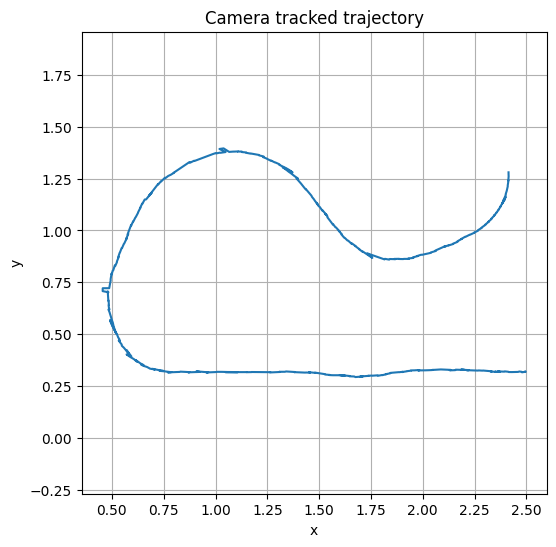

In [51]:
from rosbags.highlevel import AnyReader
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


x_vals = []
y_vals = []
t_vals = []
yaw_vals = []
Vx_vals = []
Vy_vals = []
t_inp_vals = []
inp_vals = []

with AnyReader(bag_files) as reader:
    connections = [c for c in reader.connections if c.topic == "/KF_state_estimate"]

    for connection, timestamp, rawdata in reader.messages(connections=connections):
        msg = reader.deserialize(rawdata, connection.msgtype)

        x_vals.append(msg.x)
        y_vals.append(msg.y)
        yaw_vals.append(msg.yaw)
        Vx_vals.append(msg.vb_x)
        Vy_vals.append(msg.vb_y)
        t_vals.append(timestamp * 1e-9)  # ns → sec
inp_vals = []
with AnyReader(bag_files) as reader:
    connections = [c for c in reader.connections if c.topic == "/purepursuit_target"]

    for connection, timestamp, rawdata in reader.messages(connections=connections):
        msg = reader.deserialize(rawdata, connection.msgtype)

        inp_vals.append(msg.servo_angle)
        t_inp_vals.append(timestamp * 1e-9)  # ns → sec


x_vals = np.array(x_vals)
y_vals = np.array(y_vals)
yaw_vals = np.array(yaw_vals)
Vx_vals = np.array(Vx_vals)
Vy_vals = np.array(Vy_vals)
t_vals = np.array(t_vals)
inp_vals = np.array(inp_vals)
t_inp_vals = np.array(t_inp_vals)
plt.figure(figsize=(6,6))
plt.plot(x_vals, y_vals)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Camera tracked trajectory")
plt.axis("equal")
plt.grid(True)
plt.show()

In [ ]:
shape = (len(inp_vals),)
plt.figure(figsize=(10,4))
plt.plot( np.deg2rad(inp_vals), label="servo angle")
plt.xlabel("time (s)")
plt.ylabel("servo angle (rad)")
plt.grid(True)
plt.show()

dt_i = np.mean(np.diff(t_inp_vals))
dt_i

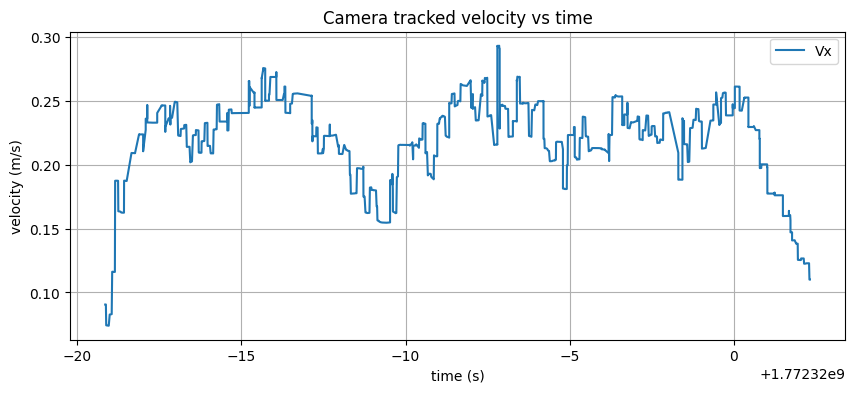

In [53]:
plt.figure(figsize=(10,4))
plt.plot(t_vals, abs(Vx_vals), label="Vx")
# plt.plot(t_vals, Vy_vals, label="Vy")

plt.xlabel("time (s)")
plt.ylabel("velocity (m/s)")
plt.title("Camera tracked velocity vs time")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(t_vals, yaw_vals)
plt.xlabel("time (s)")
plt.ylabel("yaw (rad)")
plt.title("Camera tracked yaw vs time")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

yaw = np.array(yaw_vals)
t   = np.array(t_vals)

yaw_cont = np.zeros_like(yaw)
yaw_cont[0] = yaw[0]

MAX_RATE = 8.0   # rad/sec (adjust for fish, 5–15 typical)

for k in range(1, len(yaw)):
    dt = t[k] - t[k-1]
    if dt <= 0:
        yaw_cont[k] = yaw_cont[k-1]
        continue

    dy = yaw[k] - yaw[k-1]

    # wrap to [-pi,pi]
    dy = np.arctan2(np.sin(dy), np.cos(dy))

    # rate check (detect camera glitch)
    rate = abs(dy/dt)

    if rate > MAX_RATE:
        # camera glitch → ignore jump
        dy = 0.0

    yaw_cont[k] = yaw_cont[k-1] + dy

plt.plot(t, yaw_cont)
# plt.plot(t,np.deg2rad(inp_vals), label="servo angle")
plt.title("unwrapped yaw")
plt.legend()
plt.show()

In [ ]:
from scipy.signal import savgol_filter
import numpy as np
import matplotlib.pyplot as plt

# ensure numpy arrays
t = np.array(t_vals)
x = np.array(x_vals)
y = np.array(y_vals)
print("t shape:", t.shape)
print("x shape:", x.shape)
print("y shape:", y.shape)

# sampling time (assume nearly uniform)
dt = np.mean(np.diff(t))

# window must be odd and > polyorder
window = 81# increase if noisy
poly = 3

vx = savgol_filter(x, window, poly, deriv=1, delta=dt)
vy = savgol_filter(y, window, poly, deriv=1, delta=dt)
yaw_vals = savgol_filter(yaw_vals, window, poly, delta=dt)

ux = -vy * np.sin(yaw_vals) + vx * np.cos(yaw_vals)
uy = vy * np.cos(yaw_vals) + vx * np.sin(yaw_vals)

# plot
plt.figure()
plt.plot(t, abs(ux), label="vx")
# plt.plot(t, vy, label="vy")

plt.legend()
plt.xlabel("time (s)")
plt.ylabel("velocity")
plt.title("Velocity from camera differentiation")
plt.grid(True)
plt.show()